In [12]:
# Disaster Tweets NLP Competition

# 1. Import libraries
# 2. Load train/test/sample_submission
# 3. Dataset inspection
# 4. Missing-value analysis
# 5. Text cleaning
# 6. Train/validation split
# 7. TF-IDF
# 8. Logistic Regression
# 9. Validation metrics
# 10. Test prediction
# 11. submission.csv

In [13]:
import pandas as pd
import numpy as np
import os

print(os.getcwd())
print(os.listdir("/"))

/content
['media', 'opt', 'bin', 'lib64', 'sys', 'home', 'usr', 'var', 'boot', 'etc', 'root', 'run', 'lib', 'srv', 'mnt', 'tmp', 'proc', 'sbin', 'dev', 'content', 'kaggle', '.dockerenv', 'tools', 'datalab', 'python-apt', 'python-apt.tar.xz', 'bin.usr-is-merged', 'sbin.usr-is-merged', 'lib.usr-is-merged']


In [14]:
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')
sample_submission = pd.read_csv('/content/sample_submission.csv')

print("Train: ", train.shape)
print("Test: ", test.shape)
print("Submission: ", sample_submission.shape)

Train:  (7613, 5)
Test:  (3263, 4)
Submission:  (3263, 2)


In [15]:
train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [16]:
print(train.isnull().sum())

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


In [17]:
print(train["target"].value_counts())

target
0    4342
1    3271
Name: count, dtype: int64


In [18]:
print(train["target"].value_counts(normalize=True))

target
0    0.57034
1    0.42966
Name: proportion, dtype: float64


In [19]:
for i in range(10):
    print("Tweet:", train.loc[i, "text"])
    print("Target:", train.loc[i, "target"])
    print("-" * 80)

Tweet: Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
Target: 1
--------------------------------------------------------------------------------
Tweet: Forest fire near La Ronge Sask. Canada
Target: 1
--------------------------------------------------------------------------------
Tweet: All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
Target: 1
--------------------------------------------------------------------------------
Tweet: 13,000 people receive #wildfires evacuation orders in California 
Target: 1
--------------------------------------------------------------------------------
Tweet: Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school 
Target: 1
--------------------------------------------------------------------------------
Tweet: #RockyFire Update => California Hwy. 20 closed in both directions due to Lake County fire - #CAfire #wild

In [20]:
sample_submission.head()

,id,target
0,0,0
1,2,0
2,3,0
3,9,0
4,11,0


In [21]:
print(sample_submission.columns)

Index(['id', 'target'], dtype='object')


In [22]:
print("Train columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

Train columns:
['id', 'keyword', 'location', 'text', 'target']

Test columns:
['id', 'keyword', 'location', 'text']


In [23]:
print(train["target"].value_counts())
print(train["target"].value_counts(normalize=True) * 100)

target
0    4342
1    3271
Name: count, dtype: int64
target
0    57.034021
1    42.965979
Name: proportion, dtype: float64


In [24]:
print(train.isnull().sum())

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


In [25]:
for i in range(10):
    print(f"Tweet {i}:")
    print(train.loc[i, "text"])
    print("Target:", train.loc[i, "target"])
    print("-" * 80)

Tweet 0:
Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
Target: 1
--------------------------------------------------------------------------------
Tweet 1:
Forest fire near La Ronge Sask. Canada
Target: 1
--------------------------------------------------------------------------------
Tweet 2:
All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
Target: 1
--------------------------------------------------------------------------------
Tweet 3:
13,000 people receive #wildfires evacuation orders in California 
Target: 1
--------------------------------------------------------------------------------
Tweet 4:
Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school 
Target: 1
--------------------------------------------------------------------------------
Tweet 5:
#RockyFire Update => California Hwy. 20 closed in both directions due to Lake County fire - #

In [26]:
print("Duplicate tweets:", train["text"].duplicated().sum())
duplicates = train[train["text"].duplicated(keep=False)].sort_values("text")

duplicates[["text", "target"]].head(20)

Duplicate tweets: 110


,text,target
4290,#Allah describes piling up #wealth thinking it...,0
4299,#Allah describes piling up #wealth thinking it...,0
4312,#Allah describes piling up #wealth thinking it...,1
6363,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
6373,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
6377,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
6378,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
6392,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
6366,#Bestnaijamade: 16yr old PKK suicide bomber wh...,1
2828,#KCA #VoteJKT48ID 12News: UPDATE: A family of ...,1


In [27]:
print(
    train.groupby("target")["text"]
    .count()
)

target
0    4342
1    3271
Name: text, dtype: int64


In [28]:
print("REAL DISASTER EXAMPLES\n")

for text in train[train["target"] == 1]["text"].head(5):
    print("-", text)

print("\n" + "=" * 80)

print("NON-DISASTER EXAMPLES\n")

for text in train[train["target"] == 0]["text"].head(5):
    print("-", text)

REAL DISASTER EXAMPLES

- Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
- Forest fire near La Ronge Sask. Canada
- All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
- 13,000 people receive #wildfires evacuation orders in California 
- Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school 

NON-DISASTER EXAMPLES

- What's up man?
- I love fruits
- Summer is lovely
- My car is so fast
- What a goooooooaaaaaal!!!!!!


In [29]:
print(train["keyword"].value_counts().head(20))

keyword
fatalities     45
deluge         42
armageddon     42
damage         41
body%20bags    41
harm           41
sinking        41
evacuate       40
outbreak       40
fear           40
siren          40
windstorm      40
collided       40
twister        40
hellfire       39
famine         39
flames         39
weapon         39
wreckage       39
sunk           39
Name: count, dtype: int64


In [30]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [31]:
example = train["text"].iloc[0]

print("Original:")
print(example)

print("\nCleaned:")
print(clean_text(example))

Original:
Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all

Cleaned:
our deeds are the reason of this earthquake may allah forgive us all


In [32]:
train["clean_text"] = train["text"].apply(clean_text)
test["clean_text"] = test["text"].apply(clean_text)

In [33]:
train.head()

,id,keyword,location,text,target,clean_text
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1,our deeds are the reason of this earthquake ma...
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,forest fire near la ronge sask. canada
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1,all residents asked to 'shelter in place' are ...
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1,"13,000 people receive wildfires evacuation ord..."
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1,just got sent this photo from ruby alaska as s...


In [34]:
train[["text", "clean_text", "target"]].head(10)

,text,clean_text,target
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...,1
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask. canada,1
2,All residents asked to 'shelter in place' are ...,all residents asked to 'shelter in place' are ...,1
3,"13,000 people receive #wildfires evacuation or...","13,000 people receive wildfires evacuation ord...",1
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...,1
5,#RockyFire Update => California Hwy. 20 closed...,rockyfire update => california hwy. 20 closed ...,1
6,#flood #disaster Heavy rain causes flash flood...,flood disaster heavy rain causes flash floodin...,1
7,I'm on top of the hill and I can see a fire in...,i'm on top of the hill and i can see a fire in...,1
8,There's an emergency evacuation happening now ...,there's an emergency evacuation happening now ...,1
9,I'm afraid that the tornado is coming to our a...,i'm afraid that the tornado is coming to our a...,1


In [35]:
X = train["clean_text"]
y = train["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7613,)
y shape: (7613,)


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 6090
Validation samples: 1523


In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)

Training TF-IDF shape: (6090, 14083)
Validation TF-IDF shape: (1523, 14083)


In [38]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [39]:
y_pred = model.predict(X_val_tfidf)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_val, y_pred)

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.8181221273801708


In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.90      0.85       869
           1       0.84      0.71      0.77       654

    accuracy                           0.82      1523
   macro avg       0.82      0.80      0.81      1523
weighted avg       0.82      0.82      0.82      1523



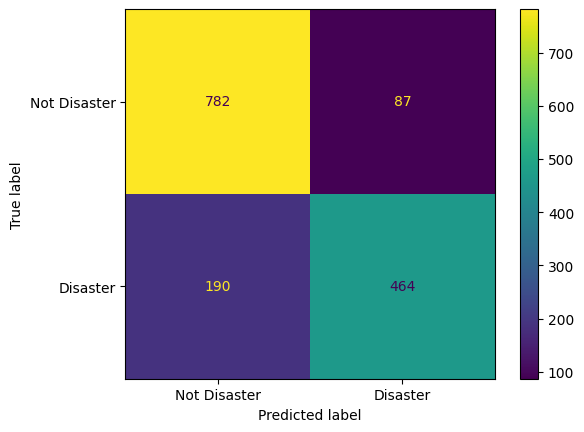

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Disaster", "Disaster"]
)

disp.plot()
plt.show()

In [42]:
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

important_features = sorted(
    zip(coefficients, feature_names)
)

print("Words associated with non-disaster:")

for coefficient, word in important_features[:20]:
    print(word, coefficient)

print("\nWords associated with disaster:")

for coefficient, word in important_features[-20:][::-1]:
    print(word, coefficient)

Words associated with non-disaster:
you -3.9573998367338885
my -3.271770650370711
new -1.9897051453192915
love -1.7164858595228984
full -1.5332819571549954
body -1.4982109977569247
he -1.4652242175242407
me -1.453126042328364
your -1.3494239258365324
or -1.342489846041205
let -1.3254939482181411
traumatised -1.3219018069481936
so -1.3137081287675612
all -1.290294403567466
bloody -1.2863736079337384
wrecked -1.267291872596984
his -1.2434551109058039
flattened -1.2400932518203518
bags -1.2162020138563243
screams -1.2100492723287521

Words associated with disaster:
in 3.568626828964986
hiroshima 3.0232698019379645
fires 2.45872908204454
california 2.458070712618086
storm 2.42787664475979
fire 2.304960963203751
train 2.0627211204438107
wildfire 2.057218665996198
killed 2.0185348781927748
suicide 2.0002610676637347
police 1.9342606806189138
floods 1.877746272318197
near 1.8565565032586788
bombing 1.8125851569061675
massacre 1.8037727495100537
buildings 1.7938347251644389
after 1.78103097485

In [43]:
X_test = test["clean_text"]

X_test_tfidf = tfidf.transform(X_test)

print("Test TF-IDF shape:", X_test_tfidf.shape)

Test TF-IDF shape: (3263, 14083)


In [44]:
test_predictions = model.predict(X_test_tfidf)

print(test_predictions[:20])

[1 0 1 1 1 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0]


In [45]:
import numpy as np

print(np.unique(test_predictions, return_counts=True))

(array([0, 1]), array([2172, 1091]))


In [47]:
submission = pd.DataFrame({
    "id": sample_submission["id"],
    "target": test_predictions
})
submission.head(10)

,id,target
0,0,1
1,2,0
2,3,1
3,9,1
4,11,1
5,12,1
6,21,0
7,22,0
8,27,0
9,29,0


In [48]:
print("Submission shape:", submission.shape)
print("Test shape:", test.shape)

print("\nSubmission columns:")
print(submission.columns.tolist())

print("\nMissing values:")
print(submission.isnull().sum())

Submission shape: (3263, 2)
Test shape: (3263, 5)

Submission columns:
['id', 'target']

Missing values:
id        0
target    0
dtype: int64


In [51]:
submission.to_csv("submission.csv", index=False)

import os

print(os.path.exists("submission.csv"))
pd.read_csv("submission.csv").head()

True


,id,target
0,0,1
1,2,0
2,3,1
3,9,1
4,11,1
